In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [3]:

BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GREY = '#888888'

buckets = ['super_short', 'short', 'medium', 'long']

In [4]:

# Full-data fine-tuned
full_acc = [80.0, 83.0, 89.0, 89.0]
full_f1  = [80.0, 82.0, 88.0, 88.0]

# Per-bucket fine-tuned
bucket_acc = [79.3, 81.0, 82.2, 89.1]
bucket_f1  = [79.0, 81.0, 83.0, 89.0]

# Frozen full-data (updated resultss)
frozen_acc = [64.0, 69.0, 72.0, 70.0]
frozen_f1  = [62.0, 68.0, 69.0, 67.0]


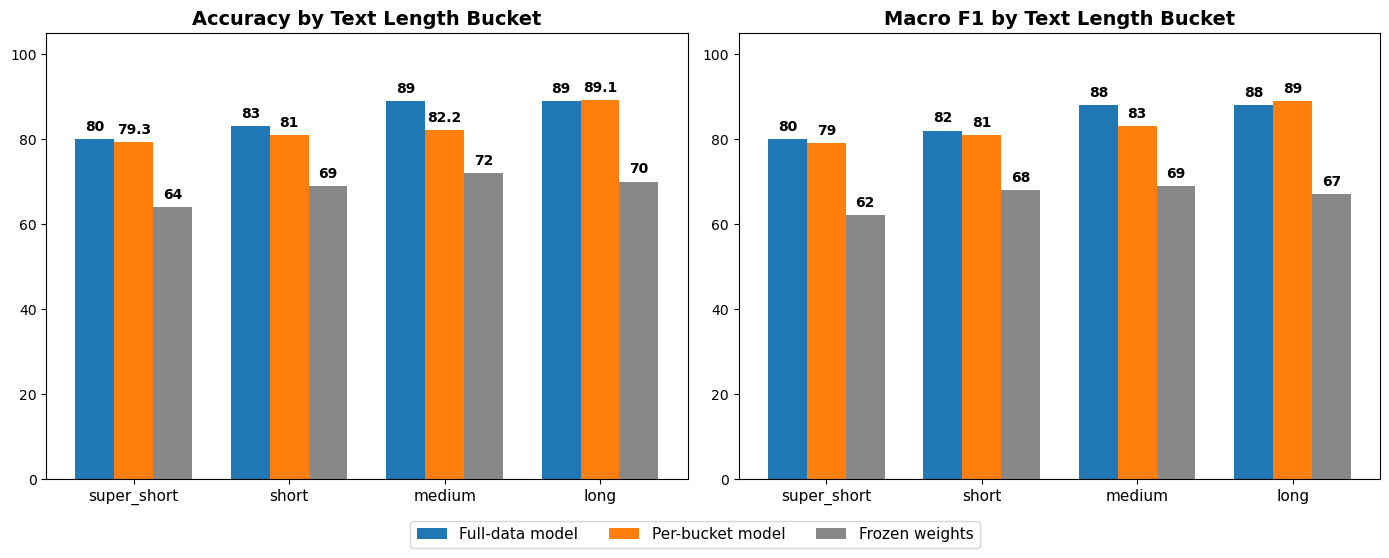

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(buckets))
width = 0.25

for ax, m_full, m_bucket, m_frozen, title in [
    (axes[0], full_acc, bucket_acc, frozen_acc, 'Accuracy by Text Length Bucket'),
    (axes[1], full_f1, bucket_f1, frozen_f1, 'Macro F1 by Text Length Bucket'),
]:
    bars1 = ax.bar(x - width, m_full, width, label='Full-data model', color=BLUE)
    bars2 = ax.bar(x, m_bucket, width, label='Per-bucket model', color=ORANGE)
    bars3 = ax.bar(x + width, m_frozen, width, label='Frozen weights', color=GREY)
    
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            label = f'{height:.0f}' if height == int(height) else f'{height:.1f}'
            ax.annotate(label,
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 4), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(buckets, fontsize=11)
    ax.set_ylim(0, 105)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.subplots_adjust(bottom=0.12)

In [6]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
})

models = {
    'Basic NB':          {'acc': [69.7, 71.1, 72.8, 66.6], 'f1': [66.1, 71.1, 72.5, 66.4], 'color': '#888780', 'ls': ':', 'marker': 'v'},
    'Advanced NB':       {'acc': [78.5, 73.6, 73.6, 66.3], 'f1': [77.0, 71.7, 68.1, 56.3], 'color': '#B4B2A9', 'ls': '--', 'marker': 'v'},
    'Basic LR':          {'acc': [73.7, 75.7, 78.7, 77.8], 'f1': [70.6, 73.2, 77.5, 75.7], 'color': '#1D9E75', 'ls': ':', 'marker': 's'},
    'Advanced LR':       {'acc': [75.0, 73.4, 76.7, 78.4], 'f1': [72.7, 72.7, 75.9, 75.2], 'color': '#5DCAA5', 'ls': '--', 'marker': 's'},
    'LSTM':              {'acc': [76.0, 77.0, 80.0, 75.0], 'f1': [75.0, 77.0, 79.0, 75.0], 'color': '#D85A30', 'ls': '-.',  'marker': 'D'},
    'BERT (frozen)':     {'acc': [64.0, 69.0, 72.0, 70.0], 'f1': [62.0, 68.0, 69.0, 67.0], 'color': '#999999', 'ls': '--', 'marker': 'x'},
    'BERT (fine-tuned)': {'acc': [80.0, 83.0, 89.0, 89.0], 'f1': [80.0, 82.0, 88.0, 88.0], 'color': '#2B5C8A', 'ls': '-',  'marker': 'o'},
}


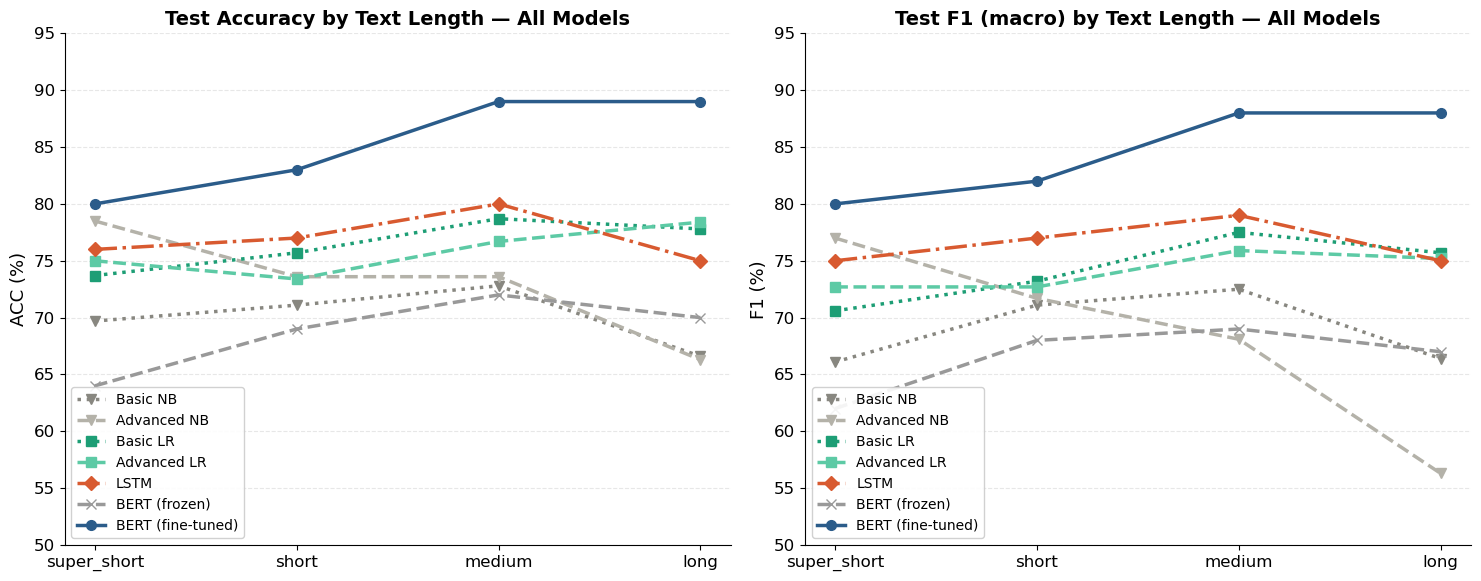

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, key, title in [
    (axes[0], 'acc', 'Test Accuracy by Text Length — All Models'),
    (axes[1], 'f1', 'Test F1 (macro) by Text Length — All Models'),
]:
    for name, m in models.items():
        ax.plot(buckets, m[key], label=name, color=m['color'],
                linestyle=m['ls'], marker=m['marker'], markersize=7,
                linewidth=2.5)
    
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylim(50, 95)
    ax.set_ylabel(key.upper() + ' (%)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(loc='lower left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()